# Cheated library: can the plain `ProfileMLP` learn the TRUE top-500 variants once it sees them directly?

Follow-up to `MLP_bilinear_head_anticorrelated.ipynb` / `MLP_for_anticorrelated_weights.ipynb`. Those
notebooks found that a plain `ProfileMLP` (no bilinear head) badly under-predicts the TRUE top-K
global-optimum variants -- the ones dominated by `J` (pairwise/epistatic), not `F` (additive) -- when
those variants are never seen during training. That's consistent with two very different explanations:

1. **Out-of-distribution / generalization gap**: the model *could* represent these points fine, it just
   never saw anything resembling them in the random training pool (the TRUE top-500 are an astronomically
   rare corner of `20**7` possible sequences).
2. **Capacity / optimization limit**: a plain MLP genuinely struggles to fit exact bilinear (Potts-style)
   structure, even if given direct supervision on those exact points.

This notebook is a pure **cheat control** to tell those two apart: retrieve the TRUE top-500 variants by
brute force against the ground-truth `F`/`J` landscape (same `K_BEST = 500` convention as
`MLP_bilinear_head_anticorrelated.ipynb` section 5), inject them **with their true ground-truth scores**
directly into the training set of the plain `ProfileMLP` (NOT the bilinear-head variant), and check
whether merely seeing them during training is enough to fix the prediction gap.

- If cheating **collapses** the gap (predicted values for the top-500 cluster at the right edge, residual
  vs. `J_part` flattens toward 0) -> the earlier failure was mostly an OOD/generalization issue, not a
  hard representational ceiling.
- If cheating does **not** fix it -> the plain MLP struggles to fit these points even in-sample, despite
  being handed the exact right answer for them -- a genuine capacity/optimization limit.

Same ground truth (`F_viab`/`J_viab`, real AAV9), same anticorrelated `F_sel`/`J_sel`
(`anticorrelation=0.2`, `key=10`), and the same cached datasets as the sibling notebooks.

## 0. Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as the sibling notebooks.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from flax import nnx
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_anticorrelated_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]


## 1. Ground truth + cached datasets

Same `F_viab`/`J_viab` (real AAV9) and `F_sel_anti`/`J_sel_anti` (`anticorrelation=0.2`, `key=10`) as
`MLP_for_anticorrelated_weights.ipynb` and `MLP_bilinear_head_anticorrelated.ipynb`, and the same
`sequences`/`sequences2` (identical seeds), so `dataset_filename` resolves to the exact CSVs those
notebooks already cached on disk -- no new simulation needed here.

F_viab shape: (20, 7)   J_viab shape: (7, 7, 20, 20)


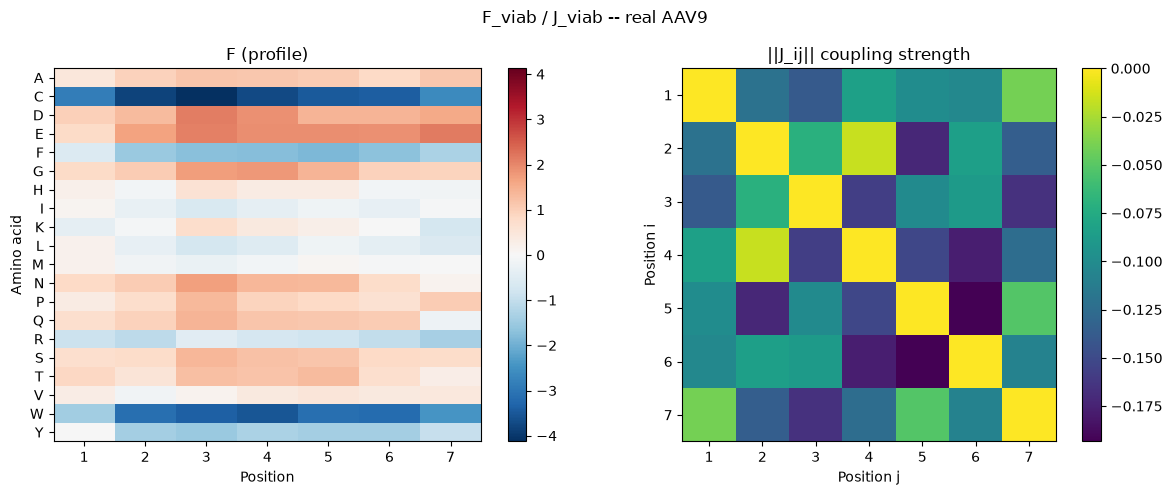

In [3]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

anticorrelation = 0.2
F_sel_anti, J_sel_anti = initialize_anticorrelated_weights(jax.random.key(10), F_viab, J_viab, anticorrelation)

print(f"F_viab shape: {F_viab.shape}   J_viab shape: {J_viab.shape}")
_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9")
plt.show()

In [4]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters -- identical to the sibling notebooks' version. Loads
    the CSV from disk if it was already generated for this exact (diversity, T_sel, T_viab, noise,
    label) combination, else builds and saves it."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df

In [5]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

dataset_anti = build_or_load_dataset(protocol_anti, sequences, None, None, label="ac")
print(f"dataset_anti: {len(dataset_anti):,} rows")
dataset_anti.head()

diversity20000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti: 20,000 rows


,sequence,target1,target2
0,DDTSNIP,1.844218,-10.276351
1,MSTDFNG,-0.194703,-0.012255
2,CQNSWCF,-7.772977,-3.401197
3,CRCHSEA,-9.877888,-0.693147
4,QAFNMTQ,-3.928573,0.309296


In [6]:
key = jax.random.key(42)
key, k_seq = jax.random.split(key)

N = 2_000_000
sequences2 = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti2 = ProtocolV3(N0=1_000_000_000, N1=500_000_000,
        dilution_factor=10, sequences=sequences2, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

dataset_anti2 = build_or_load_dataset(protocol_anti2, sequences2, None, None, label="ac")
print(f"dataset_anti2: {len(dataset_anti2):,} rows")

diversity2000000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk
dataset_anti2: 2,000,000 rows


## 2. Encode sequences, train/val/test split

In [7]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_anti["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_anti), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_anti), -1)

y_viab_all = dataset_anti["target1"].to_numpy()
y_sel_all  = dataset_anti["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_anti)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]
seq_matrix_test       = seq_matrix[idx_test]
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
y_sel_train,  y_sel_test  = y_sel_all[idx_train],  y_sel_all[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


## 3. Retrieve the TRUE top-500 variants (brute force against the ground truth)

Exhaustively scores every one of the `20**7` possible sequences against the ground-truth `F`/`J`
(identical `brute_force_top_k` recipe to the sibling notebooks -- a few seconds on GPU, chunked so
the full array is never materialized) and keeps the top `K_BEST = 500`, separately for viability
(`F_viab`/`J_viab`) and selectivity (`F_sel_anti`/`J_sel_anti`) -- same K as
`MLP_bilinear_head_anticorrelated.ipynb` section 5.

In [8]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks. Identical recipe to the sibling notebooks."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 500
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

print(f"TRUE global-optimum viability score:   {best_scores_viab[0]:.2f}")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}")

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 46.20it/s]

TRUE global-optimum viability score:   35.48
TRUE global-optimum selectivity score: 19.39


In [9]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

# Sanity check: none of the TRUE top-500 leaked into X_test -- otherwise the test-set generalization
# check in section 7 would be contaminated. With 20**7 ~= 1.3e9 possible sequences and only a
# 10,000-row test set drawn from a random 20,000-sequence pool, overlap should be zero.
test_set = {tuple(row) for row in seq_matrix_test}
overlap_viab = sum(tuple(row) in test_set for row in best_seqs_viab)
overlap_sel  = sum(tuple(row) in test_set for row in best_seqs_sel)
print(f"overlap of TRUE top-{K_BEST} with X_test: viability={overlap_viab}  selectivity={overlap_sel}")
assert overlap_viab == 0 and overlap_sel == 0, "TRUE-best variants leaked into the test set"

# Background: predicted-score distribution over the 2M-variant random sample, per model (section 8).
seq_bytes2  = np.frombuffer("".join(dataset_anti2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_anti2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_anti2), -1)

print(f"X_best_viab shape: {X_best_viab.shape}   X_big shape: {X_big.shape}")

overlap of TRUE top-500 with X_test: viability=0  selectivity=0
X_best_viab shape: (500, 140)   X_big shape: (2000000, 140)


## 4. Model: plain `ProfileMLP` (no bilinear head)

Identical architecture to the `ProfileMLP` baseline in `MLP_bilinear_head_anticorrelated.ipynb` --
Linear + BatchNorm + Dropout + gelu, twice, then a scalar linear head. No `BilinearHead` / Potts term
here on purpose: the question this notebook asks is whether the plain MLP can fit these points once
they're literally in its training set, not whether an architectural change helps.

In [10]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Identical to the sibling notebooks' ProfileMLP
    (Linear + BatchNorm + Dropout + gelu).
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)

In [11]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.jit
def predict_log_enrichment(model, x):
    return model(x, train=False)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss

In [12]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True):
    rngs = nnx.Rngs(seed)
    model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                        dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history

## 5. Build the "cheated" training set -- inject the TRUE top-500 with their TRUE scores

Same val split as a normal run (`val_frac=0.15`, `seed=0`/`1`), held on the ORIGINAL random pool only
-- so early stopping still reflects ordinary generalization, not memorization of the cheat points. The
TRUE top-500 (one-hot encoded, `K_BEST=500` from section 3) are appended **only to the train fold**,
with their ground-truth `compute_score` (`best_scores_viab` / `best_scores_sel`) as the training target
-- `compute_score` is exactly the noiseless quantity the simulated log-enrichment targets are built to
approximate (`T_sel=T_viab=1` in the protocol above), the same convention
`MLP_bilinear_head_anticorrelated.ipynb` section 6 uses when comparing `predicted - best_scores`
directly. Viability and selectivity get their own top-500 (different `F`/`J`), so they're cheated
independently.

In [13]:
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
Xtr_sel,  ytr_sel,  Xva_sel,  yva_sel  = split_train_val(X_train_full, y_sel_train,  val_frac=0.15, seed=1)
input_dim = X_train_full.shape[1]

Xtr_viab_cheat = np.concatenate([Xtr_viab, X_best_viab], axis=0)
ytr_viab_cheat = np.concatenate([ytr_viab, best_scores_viab], axis=0)
Xtr_sel_cheat  = np.concatenate([Xtr_sel,  X_best_sel],  axis=0)
ytr_sel_cheat  = np.concatenate([ytr_sel,  best_scores_sel],  axis=0)

print(f"train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}  input_dim: {input_dim}")
print(f"viability   train -> cheated: {len(Xtr_viab):,} -> {len(Xtr_viab_cheat):,}  (+{K_BEST} TRUE-best variants)")
print(f"selectivity train -> cheated: {len(Xtr_sel):,} -> {len(Xtr_sel_cheat):,}  (+{K_BEST} TRUE-best variants)")

train: 8,500  val: 1,500  test: 10,000  input_dim: 140
viability   train -> cheated: 8,500 -> 9,000  (+500 TRUE-best variants)
selectivity train -> cheated: 8,500 -> 9,000  (+500 TRUE-best variants)


## 6. Train: clean baseline vs. cheated, viability + selectivity

In [14]:
print("Training plain ProfileMLP -- viability, clean (no cheat)...")
model_viab_clean, hist_viab_clean = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

print("Training plain ProfileMLP -- viability, CHEATED (TRUE top-500 in train)...")
model_viab_cheat, hist_viab_cheat = train_profile_mlp(Xtr_viab_cheat, ytr_viab_cheat, Xva_viab, yva_viab, seed=0)

Training plain ProfileMLP -- viability, clean (no cheat)...


Training:  48%|████▊     | 144/300 [00:06<00:07, 21.84it/s]


Early stopping at epoch 144 (best val MSE=1.0009)
Training plain ProfileMLP -- viability, CHEATED (TRUE top-500 in train)...


Training:  38%|███▊      | 113/300 [00:02<00:04, 39.70it/s]

Early stopping at epoch 113 (best val MSE=1.0373)


In [15]:
print("Training plain ProfileMLP -- selectivity, clean (no cheat)...")
model_sel_clean, hist_sel_clean = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

print("Training plain ProfileMLP -- selectivity, CHEATED (TRUE top-500 in train)...")
model_sel_cheat, hist_sel_cheat = train_profile_mlp(Xtr_sel_cheat, ytr_sel_cheat, Xva_sel, yva_sel, seed=1)

Training plain ProfileMLP -- selectivity, clean (no cheat)...


Training:  32%|███▏      | 97/300 [00:01<00:03, 52.52it/s]


Early stopping at epoch 97 (best val MSE=2.1476)
Training plain ProfileMLP -- selectivity, CHEATED (TRUE top-500 in train)...


Training:  34%|███▍      | 103/300 [00:01<00:03, 54.38it/s]

Early stopping at epoch 103 (best val MSE=2.1833)


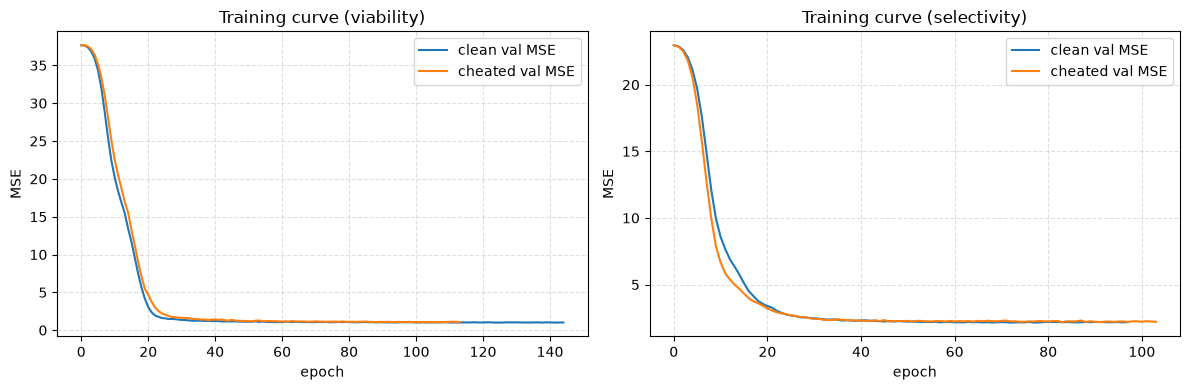

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, h_clean, h_cheat, name in [(axes[0], hist_viab_clean, hist_viab_cheat, "viability"),
                                    (axes[1], hist_sel_clean,  hist_sel_cheat,  "selectivity")]:
    ax.plot(h_clean["val_loss"], label="clean val MSE")
    ax.plot(h_cheat["val_loss"], label="cheated val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"Training curve ({name})")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 7. Test-set generalization: did cheating break anything?

`X_test` never contains any of the TRUE top-500 (checked in section 3), so this is a clean check that
adding 500 extreme points to an ~8,500-row training set didn't wreck the model's fit on the ordinary
population.

In [17]:
pred_viab_test_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_test)))
pred_viab_test_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_test)))
pred_sel_test_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_test)))
pred_sel_test_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_test)))

print(f"{'model':16s}  {'viab test r':>12s}  {'sel test r':>11s}")
print(f"{'clean':16s}  {pearson(y_viab_test, pred_viab_test_clean):12.4f}  {pearson(y_sel_test, pred_sel_test_clean):11.4f}")
print(f"{'cheated':16s}  {pearson(y_viab_test, pred_viab_test_cheat):12.4f}  {pearson(y_sel_test, pred_sel_test_cheat):11.4f}")

model              viab test r   sel test r
clean                   0.9651       0.9022
cheated                 0.9629       0.9032


## 8. Where do the TRUE-best variants land in each model's predicted distribution?

Same "Where do the TRUE-best variants land?" plot as the sibling notebooks: grey = predicted-score
distribution over the 2M-variant random background, red lines = the model's own predictions on the
TRUE top-500. For the cheated models these 500 points were literally training data -- if the plain MLP
can fit them at all, the red lines should now cluster tightly at the right edge instead of spreading
across the distribution the way the clean baseline's do.

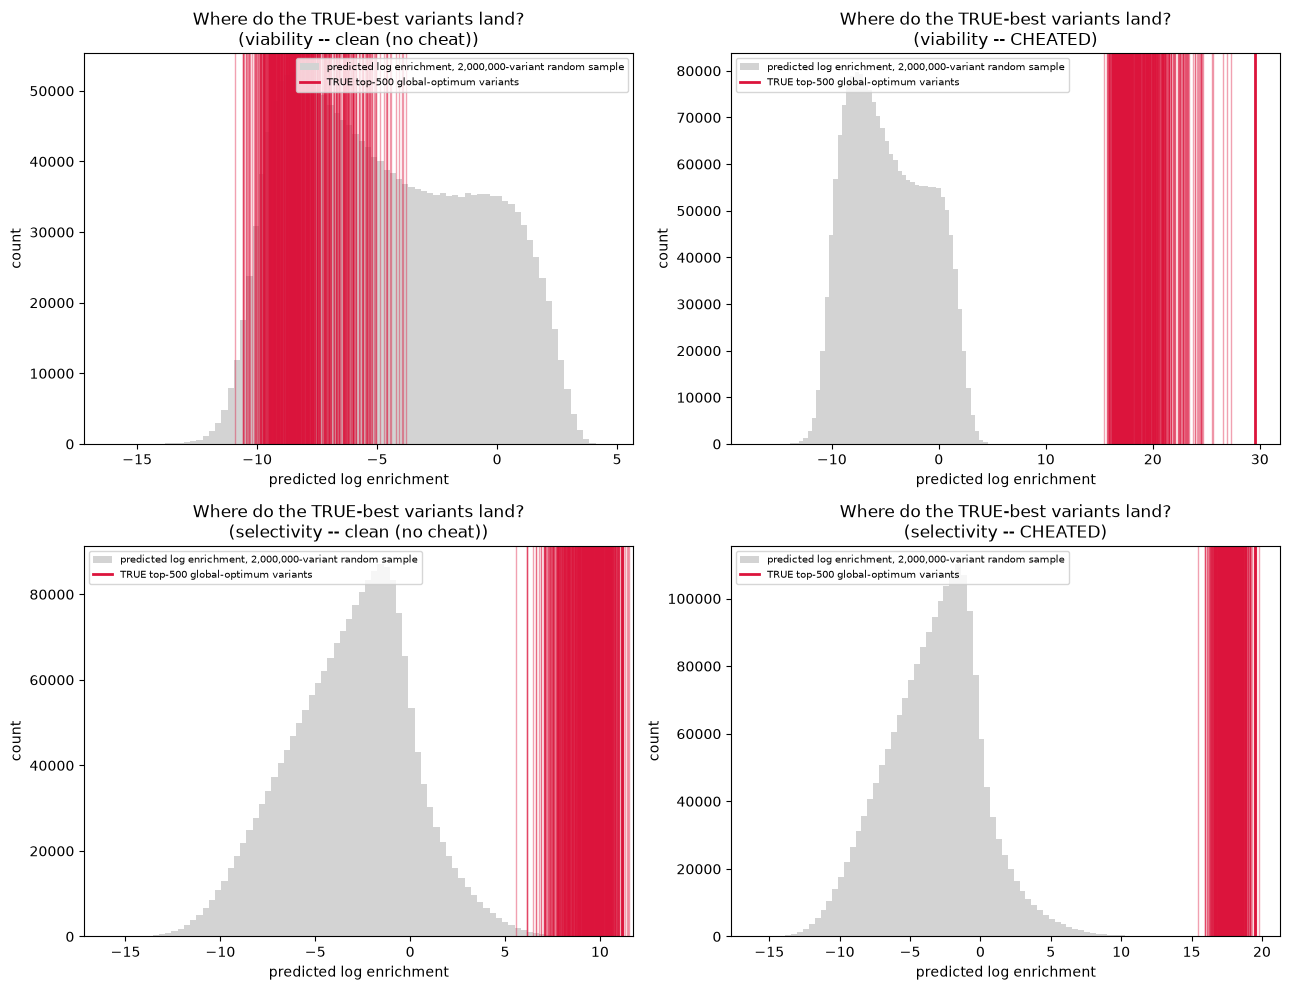

In [18]:
pred_best_viab_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_best_viab)))
pred_best_viab_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_best_viab)))
pred_best_sel_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_best_sel)))
pred_best_sel_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_best_sel)))

pred_viab_big_clean = np.asarray(predict_log_enrichment(model_viab_clean, jnp.asarray(X_big)))
pred_viab_big_cheat = np.asarray(predict_log_enrichment(model_viab_cheat, jnp.asarray(X_big)))
pred_sel_big_clean  = np.asarray(predict_log_enrichment(model_sel_clean,  jnp.asarray(X_big)))
pred_sel_big_cheat  = np.asarray(predict_log_enrichment(model_sel_cheat,  jnp.asarray(X_big)))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], pred_viab_big_clean, pred_best_viab_clean, "viability -- clean (no cheat)"),
    (axes[0, 1], pred_viab_big_cheat, pred_best_viab_cheat, "viability -- CHEATED"),
    (axes[1, 0], pred_sel_big_clean,  pred_best_sel_clean,  "selectivity -- clean (no cheat)"),
    (axes[1, 1], pred_sel_big_cheat,  pred_best_sel_cheat,  "selectivity -- CHEATED"),
]
for ax, pred_pop, pred_best, name in panels:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted log enrichment, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("predicted log enrichment")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best variants land?\n({name})")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## 9. Quantify: does the residual still correlate with `J_part`?

Decomposes each TRUE top-500 variant's ground-truth score into `F_part`/`J_part` (same recipe as the
sibling notebooks), then checks whether `residual = predicted - true` still tracks `J_part` for the
cheated model the way it does for the clean baseline. If cheating worked, `r(residual, J_part)` should
shrink toward 0 and `mean |residual|` should drop sharply for the cheated rows relative to clean.

In [19]:
def compute_F_only(seq, F, L=NUM_POSITIONS):
    """Additive part of compute_score_array -- same F[seq, arange(L)] term, without J."""
    return jnp.sum(F[seq, jnp.arange(L)], axis=1)

F_part_viab = np.asarray(compute_F_only(jnp.asarray(best_seqs_viab), F_viab))
J_part_viab = np.asarray(best_scores_viab) - F_part_viab

F_part_sel = np.asarray(compute_F_only(jnp.asarray(best_seqs_sel), F_sel_anti))
J_part_sel = np.asarray(best_scores_sel) - F_part_sel

residual_viab_clean = pred_best_viab_clean - best_scores_viab
residual_viab_cheat = pred_best_viab_cheat - best_scores_viab
residual_sel_clean  = pred_best_sel_clean  - best_scores_sel
residual_sel_cheat  = pred_best_sel_cheat  - best_scores_sel

print(f"{'group':22s}  {'r(resid, F_part)':>17s}  {'r(resid, J_part)':>17s}  {'mean |resid|':>12s}")
for label, resid, F_p, J_p in [
    ("viability, clean",     residual_viab_clean, F_part_viab, J_part_viab),
    ("viability, cheated",   residual_viab_cheat, F_part_viab, J_part_viab),
    ("selectivity, clean",   residual_sel_clean,  F_part_sel,  J_part_sel),
    ("selectivity, cheated", residual_sel_cheat,  F_part_sel,  J_part_sel),
]:
    print(f"{label:22s}  {pearson(resid, F_p):17.4f}  {pearson(resid, J_p):17.4f}  {np.mean(np.abs(resid)):12.3f}")

group                    r(resid, F_part)   r(resid, J_part)  mean |resid|
viability, clean                   0.6308            -0.9393        26.532
viability, cheated                 0.4653            -0.7856         0.690
selectivity, clean                 0.6491            -0.7347         7.827
selectivity, cheated               0.3244            -0.3266         0.622


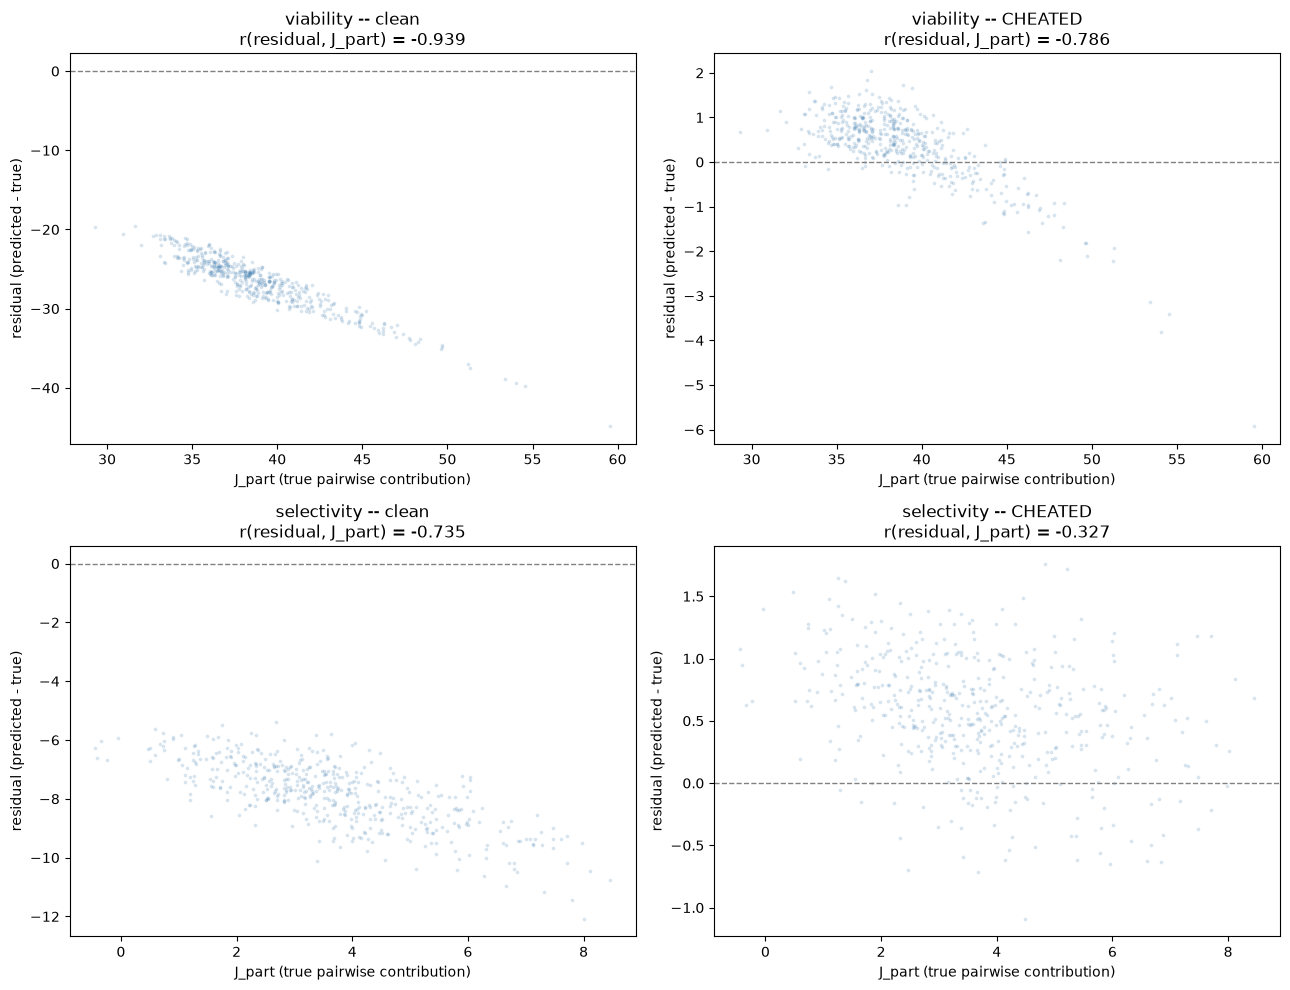

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
panels = [
    (axes[0, 0], J_part_viab, residual_viab_clean, "viability -- clean"),
    (axes[0, 1], J_part_viab, residual_viab_cheat, "viability -- CHEATED"),
    (axes[1, 0], J_part_sel,  residual_sel_clean,  "selectivity -- clean"),
    (axes[1, 1], J_part_sel,  residual_sel_cheat,  "selectivity -- CHEATED"),
]
for ax, J_p, resid, name in panels:
    r = pearson(J_p, resid)
    ax.scatter(J_p, resid, s=3, alpha=0.15, color="steelblue")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlabel("J_part (true pairwise contribution)")
    ax.set_ylabel("residual (predicted - true)")
    ax.set_title(f"{name}\nr(residual, J_part) = {r:.3f}")
fig.tight_layout()
plt.show()

## 10. Verdict

In [21]:
def variance_share(F_part, J_part):
    var_F, var_J = np.var(F_part), np.var(J_part)
    cov_FJ = np.cov(F_part, J_part)[0, 1]
    var_total = var_F + var_J + 2 * cov_FJ
    return 100 * var_F / var_total, 100 * var_J / var_total

pf, pj = variance_share(F_part_viab, J_part_viab)
print(f"Reminder -- among the TRUE top-{K_BEST} viability variants, J explains {pj:.1f}% of the")
print(f"score variance vs F's {pf:.1f}%.")
print()
print(f"{'group':22s}  {'mean |resid| (clean)':>21s}  {'mean |resid| (cheated)':>22s}")
for name, resid_c, resid_ch in [
    ("viability",   residual_viab_clean, residual_viab_cheat),
    ("selectivity", residual_sel_clean,  residual_sel_cheat),
]:
    print(f"{name:22s}  {np.mean(np.abs(resid_c)):21.3f}  {np.mean(np.abs(resid_ch)):22.3f}")
print()
print("If cheating works: mean |residual| for 'cheated' should drop sharply below 'clean', r(residual,")
print("J_part) should shrink toward 0 for the cheated rows, and the section-8 histograms' red lines")
print("should cluster tightly at the right edge for the CHEATED panels -- meaning the plain MLP CAN")
print("represent these J-dominated points once directly exposed to them, so the original gap (section")
print("4 of MLP_for_anticorrelated_weights.ipynb / section 5 of MLP_bilinear_head_anticorrelated.ipynb)")
print("is mostly an out-of-distribution / generalization problem, not a hard capacity ceiling.")
print()
print("If cheating does NOT work: residual stays large and still tracks J_part even for the cheated")
print("rows -- meaning the plain MLP genuinely struggles to fit this bilinear structure even in-sample")
print("when handed the exact right answer, pointing to a capacity/optimization limit that an explicit")
print("bilinear head (see MLP_bilinear_head_anticorrelated.ipynb) is a more principled fix for than")
print("simply enlarging or rebalancing the training set.")

Reminder -- among the TRUE top-500 viability variants, J explains 182.7% of the
score variance vs F's 32.5%.

group                    mean |resid| (clean)  mean |resid| (cheated)
viability                              26.532                   0.690
selectivity                             7.827                   0.622

If cheating works: mean |residual| for 'cheated' should drop sharply below 'clean', r(residual,
J_part) should shrink toward 0 for the cheated rows, and the section-8 histograms' red lines
should cluster tightly at the right edge for the CHEATED panels -- meaning the plain MLP CAN
represent these J-dominated points once directly exposed to them, so the original gap (section
4 of MLP_for_anticorrelated_weights.ipynb / section 5 of MLP_bilinear_head_anticorrelated.ipynb)
is mostly an out-of-distribution / generalization problem, not a hard capacity ceiling.

If cheating does NOT work: residual stays large and still tracks J_part even for the cheated
rows -- meaning the pla